<a href="https://colab.research.google.com/github/shreyas284-crtl/Data-Science-Internship/blob/main/class4_Linear_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Health Insurance Price Prediction**

### **Problem Statement**

The goal of this project is to develop a **predictive model** that accurately estimates the **medical insurance costs** for individuals based on various **demographic, lifestyle, and health-related factors**. By applying **machine learning techniques**, we aim to assist **insurance companies** in better understanding their risk profiles and help **individuals gain insights** into how different factors influence their **insurance premiums**.

### **Import Libraries**

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

##**Load Data**

In [ ]:
data = pd.read_csv('insurance.csv')
data

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


**Domain Analysis**
The descriptions of the variables based on the insurance dataset:

1. **Age**
   - **Description:** Age of the primary beneficiary covered by health insurance.
   - **Type:** Continuous numerical variable.

2. **Sex**
   - **Description:** Gender of the insurance contractor.
   - **Type:** Categorical variable with two levels: female, male.

3. **BMI (Body Mass Index)**
   - **Description:** Body mass index, which is a measure of body fat based on height and weight.
   - **Type:** Continuous numerical variable.
   - **Ideal Range:** Ideally between 18.5 to 24.9 kg/m².

4. **Children**
   - **Description:** Number of children covered by health insurance or number of dependents.
   - **Type:** Discrete numerical variable.

5. **Smoker**
   - **Description:** Binary indicator if the beneficiary is a smoker.
   - **Type:** Categorical variable with two levels: yes, no.

6. **Region**
   - **Description:** The beneficiary's residential area in the US.
   - **Type:** Categorical variable with four levels: northeast, southeast, southwest, northwest.

7. **Charges**
   - **Description:** Individual medical costs billed by health insurance.
   - **Type:** Continuous numerical variable.

### **Basic Checks**

In [ ]:
# shape : gives number of rows and columns
data.shape

(1338, 7)

There are 1338 rows and 7 columns.

In [ ]:
# head: print first 5 rows
data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [ ]:
# tail : print last 5 rows
data.tail()

,age,sex,bmi,children,smoker,region,charges
1333,50,male,30.97,3,no,northwest,10600.5483
1334,18,female,31.92,0,no,northeast,2205.9808
1335,18,female,36.85,0,no,southeast,1629.8335
1336,21,female,25.80,0,no,southwest,2007.9450
1337,61,female,29.07,0,yes,northwest,29141.3603


In [ ]:
# info: memory usage
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [ ]:
# print all columns
data.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

In [ ]:
# check the data type
data.dtypes

,0
age,int64
sex,object
bmi,float64
children,int64
smoker,object
region,object
charges,float64


In [ ]:
# print numerical columns
num_col= data.select_dtypes(include=['int64','float64'])
num_col


,age,bmi,children,charges
0,19,27.900,0,16884.92400
1,18,33.770,1,1725.55230
2,28,33.000,3,4449.46200
3,33,22.705,0,21984.47061
4,32,28.880,0,3866.85520
...,...,...,...,...
1333,50,30.970,3,10600.54830
1334,18,31.920,0,2205.98080
1335,18,36.850,0,1629.83350
1336,21,25.800,0,2007.94500


In [ ]:
# print categorical columns
cat_col= data.select_dtypes(include=['object'])
cat_col

,sex,smoker,region
0,female,yes,southwest
1,male,no,southeast
2,male,no,southeast
3,male,no,northwest
4,male,no,northwest
...,...,...,...
1333,male,no,northwest
1334,female,no,northeast
1335,female,no,southeast
1336,female,no,southwest


In [ ]:
# statiscal report for numerical column
data.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [ ]:
# statiscal report for categorical column
data.describe(include='object')

,sex,smoker,region
count,1338,1338,1338
unique,2,2,4
top,male,no,southeast
freq,676,1064,364


In [ ]:
# find unique values in categorical column
for x in cat_col:
  print(x,'-->',data[x].unique())

sex --> ['female' 'male']
smoker --> ['yes' 'no']
region --> ['southwest' 'southeast' 'northwest' 'northeast']


In [ ]:
# find value counts
for x in cat_col:
  print(data[x].value_counts())
  print()

sex
male      676
female    662
Name: count, dtype: int64

smoker
no     1064
yes     274
Name: count, dtype: int64

region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64



### **Data Cleaning**

**Check for Misisng values**

In [ ]:
data.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


Clearly no missing values.

**Check for duplicates**

In [ ]:
# duplicates : repeated values
data.duplicated().sum()

np.int64(1)

There is 1 duplicate which has to be dropped.

In [ ]:
# drop duplicates
data.drop_duplicates(inplace=True)

In [ ]:
data.duplicated().sum()

np.int64(0)

## **Exploratory Data Analysis**

###**Univariate Analysis**
Analysing single column
* Histogram
* countplot
* box plot

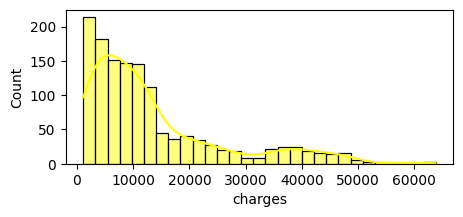

In [ ]:
# Check the distribution of charges
plt.figure(figsize=(5,2))
sns.histplot(data,x='charges',kde=True,color='yellow')
plt.show()

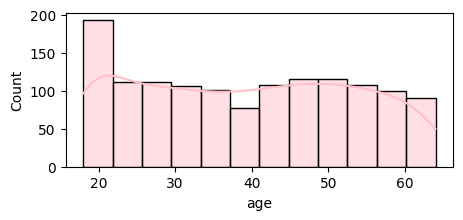

In [ ]:
# Check the distribution of age
plt.figure(figsize=(5,2))
sns.histplot(data,x='age',kde=True,color='pink')
plt.show()

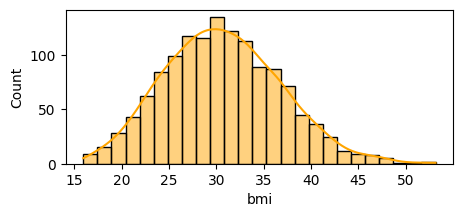

In [ ]:
#Check the distribution of bmi
plt.figure(figsize=(5,2))
sns.histplot(data,x='bmi',kde=True,color='orange')
plt.show()

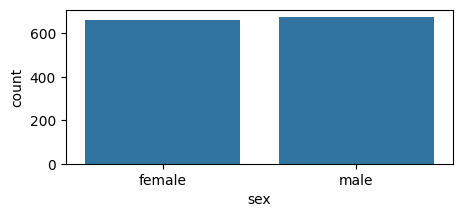

In [ ]:
# Visualise count of male and female
plt.figure(figsize=(5,2))
sns.countplot(data , x='sex')
plt.show()

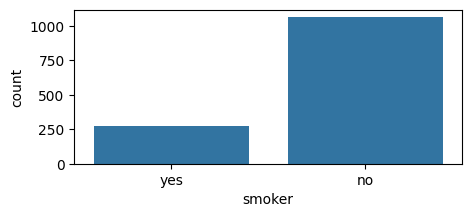

In [ ]:
# Visualise count of smokers and non smokers
plt.figure(figsize=(5,2))
sns.countplot(data , x='smoker')
plt.show()

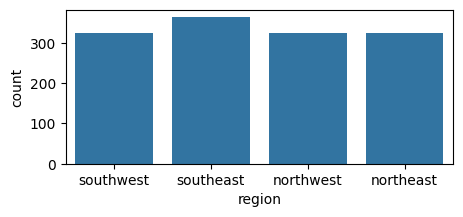

In [ ]:
# Visualise count of different region
plt.figure(figsize=(5,2))
sns.countplot(data , x='region')
plt.show()

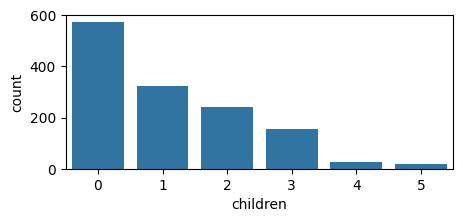

In [ ]:
# count of children
plt.figure(figsize=(5,2))
sns.countplot(data , x='children')
plt.show()

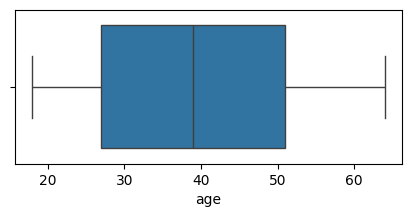

In [ ]:
# check are there any outliers in age
plt.figure(figsize=(5,2))
sns.boxplot(data,x='age')
plt.show()

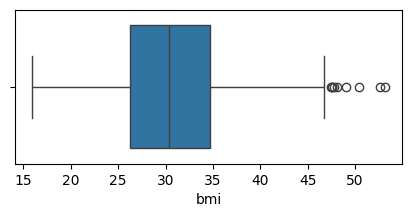

In [ ]:
# check are there any outliers in bmi
plt.figure(figsize=(5,2))
sns.boxplot(data,x='bmi')
plt.show()

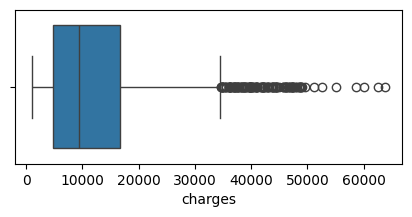

In [ ]:
# # check are there any outliers in charges
plt.figure(figsize=(5,2))
sns.boxplot(data,x='charges')
plt.show()

In [ ]:
data

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


###**Bivariate Analysis**
Analysing two variables/columns
1. scatter
2. bar plot
3. line plot

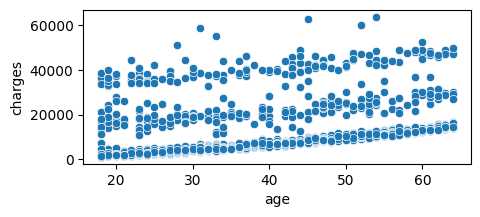

In [ ]:
# find relationship between age and charges
plt.figure(figsize=(5,2))
sns.scatterplot(data,x='age',y='charges')
plt.show()


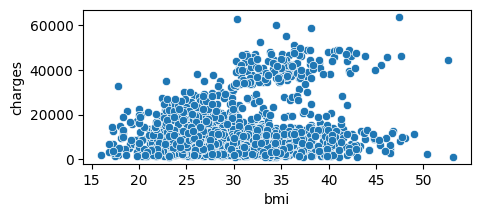

In [ ]:
# find relationship between bmi and charges
plt.figure(figsize=(5,2))
sns.scatterplot(data,x='bmi',y='charges')
plt.show()

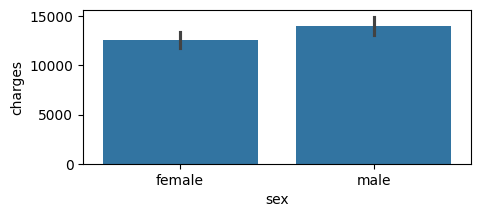

In [ ]:
# find how charges vary with gender
plt.figure(figsize=(5,2))
sns.barplot(data,x='sex',y='charges')
plt.show()

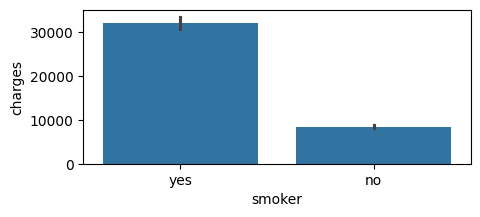

In [ ]:
# find how charges vary with smokers
# find how charges vary with gender
plt.figure(figsize=(5,2))
sns.barplot(data,x='smoker',y='charges')
plt.show()

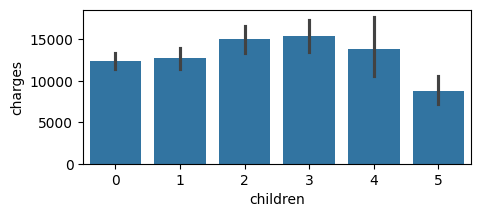

In [ ]:
# find how charges  vary with children
# find how charges vary with gender
plt.figure(figsize=(5,2))
sns.barplot(data,x='children',y='charges')
plt.show()

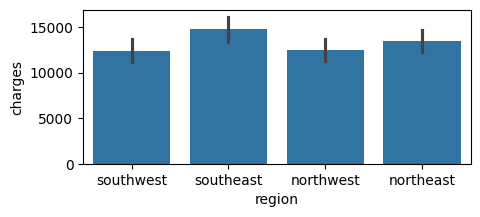

In [ ]:
# find how charges vary with region
# find how charges vary with gender
plt.figure(figsize=(5,2))
sns.barplot(data,x='region',y='charges')
plt.show()

In [ ]:
data

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


###**Multivariate Analysis**

In [ ]:
# PAIRPLOT and heat map